# Worksheet 5.1 - State-Value Prediction with Neural State Approximation


## Learning Outcomes
By the end of this worksheet, you should be able to:
- **reproduce** a linear function approximator using the neural network infrastructure (with no trunk or neck) and verify it matches the linear baseline  
- **configure and train** models of increasing complexity, adjusting the trunk and neck, and observe the effect on learning  
- **explain** why batching stabilises training and when we can or cannot introduce it in RL and compare single-step vs batched updates  
- **identify** underfitting and overfitting from learning curves and adjust the model accordingly  
- **build** a model that learns directly from pixel inputs and evaluate its performance against the linear baseline  

## From Linear Models to Neural Networks
In this worksheet, we focus on training **multi-layer neural networks** for reinforcement learning. We begin, however, with the simplest possible case: a network with no hidden layers.

By setting both the trunk and neck to None, the infrastructure reduces to a single linear layer mapping inputs directly to outputs. This is mathematically identical to the linear function approximators we studied previously — and you will verify this by confirming that the two produce the same results on the same task.

This serves two purposes. First, it gives us a sanity check: if the neural network infrastructure reproduces the linear baseline exactly, we can trust it for more complex experiments. Second, it makes a conceptual point concrete: a linear model is not a separate method but simply a special case of a neural network — one with no activation functions and no hidden layers.

From this baseline, we will gradually increase complexity. We will enable a convolutional trunk to extract spatial features from pixel observations, add a neck to compress those features, and observe how each change affects what the agent can learn and how quickly it learns it. Throughout, the workflow remains the same — only the configuration changes.

In [1]:
!cd '/Users/scsaalt/Library/CloudStorage/OneDrive-UniversityofLeeds/MScAIODLResources/RLandRobotics/1. Reinforcement Learning and Robotics/rl_rob' && git add -A && git commit -m "update" && git push --force-with-lease origin main
%cd ~/rl_rob 
!git pull

[main 8a7dfc8] update
 3 files changed, 324 insertions(+), 638 deletions(-)
fatal: unable to access 'https://github.com/AltahhanAi/rl_rob.git/': Could not resolve host: github.com
/Users/scsaalt/rl_rob
fatal: unable to access 'https://github.com/AltahhanAi/rl_rob.git/': Could not resolve host: github.com


In [2]:
from rl.linear import *
from rl.neural import *

## Neural MC

Monte Carlo methods provide an important stepping stone that allows us to understand the nuances of implementing **neural networks** in reinforcement learning. They also serve as a useful cognitive check, helping to expose some of the difficulties that arise when combining neural networks with RL, particularly in the context of **state-value prediction**.

The `nnMC` class implements **Monte Carlo** prediction using a neural network as the value function approximator. As in the standard MC setting, learning occurs only at the end of each episode. 

During an episode, the buffer stores the full trajectory. Once the episode terminates, the `offline()` method processes this trajectory by sweeping backwards through the buffer to compute the exact returns \( G_t \). These returns are then used to fit the network in a single end-of-episode update.

After the update, the buffer is cleared, ensuring that only the current episode is used for learning. This keeps the method fully consistent with the Monte Carlo framework.

Below, we show the implementation of the `nnMC` method.

In [3]:
class nnMC(nnMRP):
    
    # at the start of the run
    def init(self):
        self.nbuffer = self.max_t # nnMRP stores in a buffer always
        
    # at the start of the episode
    def step0(self):
        self.buffer.clear() # clear the buffer after each episode
    # --------------- 🌘 offline, MC learning: end-of-episode learning ----------------  
    def offline(self):
        # obtain the return for the latest episode
        Gt = 0
        for t in range(self.t, -1, -1):
            s, _, rn, _, _ = self.buffer[t]
            Gt = self.γ*Gt + rn
            Vs  = self.w(s)
            self.w.fit(Vs, Gt.view_as(Vs))           # backprop handles multilayer learning
            

In [4]:
nnmc = nnMC(env=vrandwalk(), max_t=1000, α=3e-2, γ=1, seed=1, episodes=30, **demoE)

------------------- 易  nnMC is being set up 易 ---------------------
╭───────────────────────────────────────────────────────────────────────────────────────╮
│          Model Architecture: V                                                        │
├────┬───────────────────────────┬─────────────────┬─────────────────────────┬──────────┤
│ Id │ Layer                     │ Output Shape    │ Parameters              │Trainable │
├────┼───────────────────────────┼─────────────────┼─────────────────────────┼──────────┤
│  0 │ Linear (7x1)              │ (1,)            │          7 (  0 bias)   │ Yes      │
╰───────────────────────────────────────────────────────────────────────────────────────╯
Total parameters: 7 of which 0 are bias


Now take a moment to understand the architecture that you have just created. It is a simple linear neural netowrk of one layer, which is the same architecture that we were dealing with in the last unit.

CPU times: user 10.4 s, sys: 2.29 s, total: 12.7 s
Wall time: 6.18 s


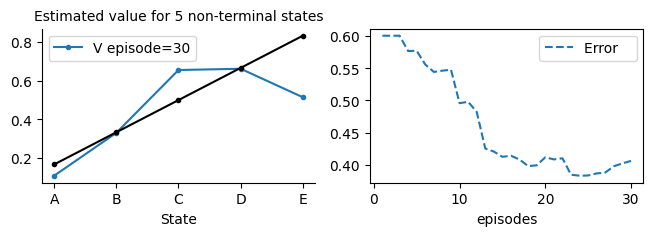

In [5]:
%time nnmc.interact()

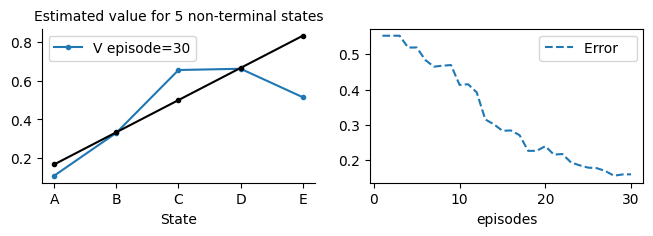

In [6]:
vmc = vMC(env=vrandwalk(), max_t=1000, α=3e-2, γ=1, seed=1, episodes=30, **demoE).interact()

## Offline Neural TD


In [7]:
class nnTDf(nnMRP):
    
    def init(self):
        self.nbuffer = self.max_t                # all nnMRP and subclasses stores 
        
    def step0(self):
        self.buffer.clear()                      # clear the buffer after each episode
    
    # --------------- 🌘 offline TD learning: end-of-episode learning ----------------  
    def offline(self):
        for t in range(self.t, -1, -1):
            s, _, rn, sn, done = self.buffer[t]
            Vs  = self.w(s)
            Vn  = self.w(sn).detach() 
            self.w.fit(Vs, self.γ*Vn + rn)       # backprop handles multilayer learning
            

In [8]:
nntdf = nnTDf(env=vrandwalk(), α=1e-1, γ=1, seed=1, episodes=100, **demoE)

------------------- 易  nnTDf is being set up 易 ---------------------
╭───────────────────────────────────────────────────────────────────────────────────────╮
│          Model Architecture: V                                                        │
├────┬───────────────────────────┬─────────────────┬─────────────────────────┬──────────┤
│ Id │ Layer                     │ Output Shape    │ Parameters              │Trainable │
├────┼───────────────────────────┼─────────────────┼─────────────────────────┼──────────┤
│  0 │ Linear (7x1)              │ (1,)            │          7 (  0 bias)   │ Yes      │
╰───────────────────────────────────────────────────────────────────────────────────────╯
Total parameters: 7 of which 0 are bias


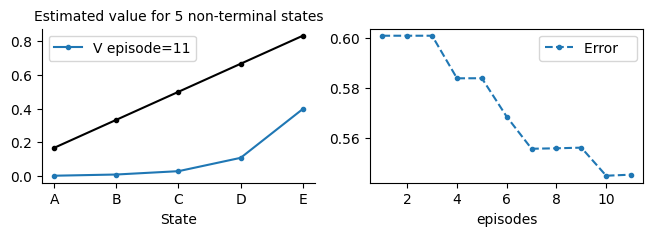

In [ ]:
%time nntdf.interact()

## Neural TD Algorihtm
Ok, now let us develop our nerual network based semi gradient TD algorithm:

In [ ]:
class nnTD(nnMRP):
    # ----------------------------- 🌖 online learning ------------------------------
    def online(self, *args):
        (s, _, rn, sn, done),_ =  self.batch(-1) # take the last sample from the buffer
        
        Vs  = self.w(s)
        Vn  = self.w(sn).detach()                # detach ensures semi-gradient
        Vn[done] = 0                             # = (1-done)*V(sn)
        
        self.w.fit(Vs, self.γ*Vn + rn)           # backprop handels multi-layer learning


In [ ]:
nntd = nnTD(env=vrandwalk(), α=1e-1, γ=1, seed=1, episodes=100, **demoE)

As we can see we have created a simple one layer neural network which is equivalent to what we have been dealing with in our previous unit. We will train this to ensure everything is working as expected.

In [ ]:
nntd.interact()

In [ ]:
vtd = vTD(env=vrandwalk(), α=1e-1, γ=1,seed=1, episodes=100, **demoE).interact()

## Learning from pixles
Now we turn into a more significant learning excercise which is what we created our network infra structure for, which is training a nerual network with multi-layers. We will actually learn from pixles of states coming from our usual environments. This time the env is actually generating images of the grid as a state.

In [ ]:
def irandwalk(**kw):  
    return randwalk(iGrid, **kw)

env = irandwalk()
img = env.reset()
img,_,_,_,_= env.step(1)

plt.imshow(img[0], cmap='gray')

env = imaze(reward='sparse')
env.reset().shape


## Neural Infrastructure: The Trunk and the Neck

We provide a ready-made, easily configurable neural network infrastructure that can be used to construct fairly powerful models with minimal effort. It is built on **PyTorch**, and its structure is controlled primarily through two components: the **trunk** and the **neck**. Recall that the **state-value function** \( V \) produces a **single scalar output**, whereas the **action-value function** \( Q \) produces **\( nA \)** outputs when the action space is discrete (or multiple components in the continuous case). For simplicity, we will assume a **discrete action space** for now.


The **trunk** is the **feature extraction** part of the network. It can consist of **multiple layers**, and is designed to learn useful representations directly from raw inputs—removing the need for manual feature engineering such as tile coding or discretisation used in earlier units. 

The trunk is specified as a **list**, which can contain:
- **tuples** → for convolutional layers: `(c, k×k, s)`
- **integers** → for fully connected layers  

where: `c` = number of output channels,  `k×k` = kernel size , `s` = stride. For example: `trunk = [(8, 4, 2), (4, 4, 4)]` defines two conv layers. The first has 8 channels, a 4×4 kernel, and a stride of 2 and a second convolutional layer with 4 channels, 4×4 kernel, and stride of 4.

The trunk always ends with a **flatten layer**, which converts the final feature maps into a vector representation.

The **neck** is the **single penultimate layer** that connects the trunk to the output (value or action-value head). It is a **fully connected layer** with **\( nF \)** features.

There is:
- a **fully connected mapping** from the trunk → neck  
- and another **fully connected mapping** from the neck → output head  

The neck, therefore, defines the **final feature representation** used for prediction.

This is directly analogous to the linear case we studied earlier:
- for \( V \): \( nF $\rightarrow$ 1 \)  
- for \( Q \): \( nF $\rightarrow$ nA \)


In earlier examples where no trunk was specified, the model effectively had:
- **no feature extraction stage**
- the **raw state vector** (of size \( nS \)) used directly as input  

In this case, we can think of it as:
- \( nF = nS \)

which matches the linear models we previously worked with.


With this setup in place, we are now ready to move beyond hand-crafted features and begin learning **directly from raw inputs such as pixels**.

In [ ]:
env = irandwalk() # provides images as states
nntd = nnTD(env=env, α=2e-4, γ=1, seed=1, episodes=120, **demoE,
          trunk=[(8, 4, 2), (4, 4, 4)], nF=env.nS) # the trunk is the feature extraction part of the network

In [ ]:
nntd.interact()

Increase the number of episodes and observe the behaviour of the algorithm. 

Of course we can run nnMC with a properneural network architecture.

In [ ]:
env = irandwalk() # provides images as states
nnmc = nnMC(env=env, α=7e-5, γ=1, seed=1, episodes=150, **demoE,
          trunk=[(8, 4, 2), (4, 4, 4)], nF=env.nS).interact() # the trunk is the feature extraction part of the network

## Stochastic and Batch Learning

As can be seen, the model becomes harder to train when we introduce more elaborate architectures with trunks and deeper representations. In particular, the **stochasticity of the states and the updates** becomes more prominent, which leads to **higher variance during learning**. As a result, relying on **single-step updates** is often insufficient, especially for neural networks, where small fluctuations in the data can significantly affect the learning dynamics.

This is where **batch training** enters the scene. As we have seen in previous modules, machine learning models generally benefit from batch updates. In fact, **batch training is the norm**, as updating using one sample at a time is typically inefficient for larger models and tends to produce **high-variance and unstable updates**, often leading to slower convergence or overfitting to individual transitions.

By aggregating multiple samples into a batch, we obtain a more reliable estimate of the gradient, which helps **stabilise learning** and improve convergence. However, in reinforcement learning this is not always straightforward, since we are dealing with **sequential and policy-dependent data**. Unless the learning algorithm is designed to accommodate batching, it is not always permissible to arbitrarily group samples together.

For example, in **on-policy methods**, using old samples is generally not permissible, as it can **corrupt the learning process**. This is because the updates must reflect the **current policy**. A common workaround is to first collect a batch of samples under the current policy, and then apply updates in batch form before the policy changes, ensuring consistency between the data and the policy being optimised.

On the other hand, for **off-policy methods** such as Q-learning, batching is more flexible. These methods are explicitly designed to learn about a **target policy that may differ from the behaviour policy**. As a result, they can reuse past experience and perform updates on previously collected data without violating the underlying assumptions. This makes techniques such as **experience replay** both valid and effective, improving stability and sample efficiency.

In summary, while **batch learning** is highly beneficial for stabilising training and reducing variance, its use in reinforcement learning depends on the nature of the algorithm, particularly whether it is **on-policy or off-policy**, and how it manages the interaction between **data and policy**.

## Neural TD with Batch Taining
In neural networks we can train multiple steps at the same time via batch training. 
This ability it trns out to be crucial particualrly when we deal with the deadly triad to stabilise the learning by replaying old trajectories in mini batches. Below we show you a TD methd that use multiple trajectories to batch train its value function. 

In [ ]:
class TDN(nnMRP):
    # ----------------------------- 🌖 online learning ----------------------  
    def online(self, *args):
        if len(self.buffer) < self.nbatch: return  # wait until we have nbatch entries in the buffer
        (s, _, rn, sn, dones), _ = self.batch() # note that we are taking a batch now instead of one buffer item
        
        Vs  = self.w(s)
        Vn  = self.w(sn).detach()
        Vn[dones] = 0
        
        self.w.fit(Vs, self.γ * Vn + rn.unsqueeze(1))

Let us now train with multiple time steps trajectoreis stored in the buffer

In [ ]:
env = irandwalk()
tdn = TDN(env=env, α=2e-4, γ=1, seed=1, episodes=100, **demoE,
          trunk=[(8, 4, 2), (4, 4, 4)], nF=env.nS,
          nbuffer=100, nbatch=16, rndbatch=True)

In [ ]:
tdn.interact()

Note how the method behaviour changed where it converge quicker and its behaviour is more stable. Note also that the method does not start to have visible changes until around 15 episodes until the buffer is filled and the random sampling taken from the buffer is becoming more effective.

Change the learnign rate and the trunk and neck architecture and observe the effect.

So we are learning from the **pixels of the random walk** NOT directly from the states.

Note how the learning is more stable.

Change the nbuffer size and the nbatch and observe the effect. This will give you a clear idea of the effect of the these hyperparameters. These are important for any neural network solution.

In [ ]:
Runs(algorithm=nnTDf(env=vrandwalk(), α=.1, γ=1, episodes=100, model_summary=False), plotE=True, runs=10).interact(label='nnMC',frmt='--')
Runs(algorithm=nnMC(env=vrandwalk(), α=.02, γ=1, episodes=100, model_summary=False), plotE=True, runs=10).interact(label='nnTDf')


In [ ]:
env = irandwalk() # provides images as states
nntd = nnMC(env=env, α=2e-4, γ=1, seed=1, episodes=120, **demoE,
          trunk=[(8, 4, 2), (4, 4, 4)], nF=env.nS).interact() # the trunk is the feature extraction part of the network

In [ ]:
env = irandwalk()
# Runs(algorithm=nnTDf(env=env, trunk=[(8, 4, 2), (4, 4, 4)], nF=env.nS, α=1e-3, γ=1, episodes=100, model_summary=False), plotE=True, runs=10).interact(label='nnMC',frmt='--')
Runs(algorithm=nnMC(env=env, trunk=[(8, 4, 2), (4, 4, 4)], nF=env.nS, α=1e-4, γ=1, episodes=100, model_summary=False), plotE=True, runs=10).interact(label='nnTDf')


### Conclusion

In this worksheet, we have introduced a complete **neural network framework** and demonstrated how to construct well-known reinforcement learning methods within it, such as `nnTD`, `nnMC`, and `TDN`. These methods mirror their classical counterparts, but operate using neural networks as function approximators.

A key takeaway is that the same underlying infrastructure can be configured to reproduce familiar algorithms, while also extending them to handle more complex settings. By adjusting the architecture, we can move from simple linear models to richer representations without changing the overall workflow.

This unified approach allows us to train agents to learn **value functions** directly from raw inputs, such as pixels, or from more structured state representations. As a result, the methods developed here provide a flexible foundation for scaling reinforcement learning from simple problems to more realistic and high-dimensional environments.